[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/04_webscraping/16_openalex_scholarly_data.ipynb)

# 📓 Notebook 16 — OpenAlex: The Open Scholarly Graph

> **Module:** Web Scraping (Module 4) · **Estimated time:** ~65 minutes · **Difficulty:** Intermediate

The last two lessons taught you to pull data *out of HTML* — fundamentals in **NB 14**, and rendered/JS-heavy pages with Firecrawl in **NB 15**. This one flips the script:

> **Before you scrape a publisher's website, look for an open API.** For scholarly literature there is a superb one — **OpenAlex**, a free, fully-open index of **~250 million** works (papers, books, datasets), plus the authors, journals, institutions, and topics that connect them. No login, no key wall, no brittle HTML selectors — just clean JSON.

Scraping a journal's search results is fragile, slow, and legally grey. Querying OpenAlex is a single tidy HTTP request that returns *structured* data with stable field names. When a good API exists, it is almost always the better "web data" source — and knowing how to recognise and use one is a core data-collection skill.

### 🧭 Mental model — the scholarly graph

OpenAlex is not a pile of documents; it is a **graph**. Five entity types are the nodes, and they link to each other along labelled edges:

```
works  ──authorships──▶  authors  ──affiliations──▶  institutions
  │                                                       ▲
  ├──primary_location──▶  sources (journals/repos)        │
  └──primary_topic────▶  topics ◀──────────────────────────
```

You **query one entity**, then **filter or expand along the edges**: "works *by* this author", "works *in* this journal *about* this topic *in* 2023". Everything in this notebook is a variation on: *pick an entity → filter → page → flatten*.

## ✅ Prerequisites

- **NB 12** — APIs, HTTP & JSON. We reuse `requests`, status codes, `try/except`, and pagination from there.
- **NB 7** — pandas. We flatten nested JSON into a `DataFrame` at the end.
- **NB 14** — web-scraping fundamentals. This lesson is the *"is there an API instead?"* branch of the decision you learned there.


## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Decide** when an open API beats scraping HTML — with OpenAlex as the worked example.
2. **Navigate** the OpenAlex scholarly graph across its entities: `works`, `authors`, `sources`, `institutions`, `topics`, `publishers`, `funders`.
3. **Request** a single entity and **read the JSON shape** of a Work (`id`, `display_name`, `publication_year`, `cited_by_count`, `authorships`, `primary_location`).
4. **Join the polite pool** with `mailto=` and respect the API's rate limits — the robots.txt-equivalent good manners for APIs.
5. **Filter** (`filter=`) and **search** (`search=`) to build precise queries by year, topic, and institution.
6. **Paginate** a large result set with a **cursor** (`cursor=*` → follow `meta.next_cursor`).
7. **Flatten** nested results into a tidy pandas `DataFrame` (guarding null fields) and **chart** a quick insight.


## 1. Don't scrape what you can query

Imagine your task is *"collect the 500 most-cited graph-learning papers since 2019, with their authors and venues."* Two roads:

| | 🕸️ Scrape a journal / Google Scholar | 🔌 Query OpenAlex |
|---|---|---|
| **Data shape** | HTML you must parse; layout changes break you | Structured JSON, stable field names |
| **Coverage** | one publisher at a time | ~250M works across all publishers |
| **Rate / blocking** | CAPTCHAs, IP bans, ToS violations | documented limits, *invites* automated use |
| **Auth** | often needs a login | **no API key required** |
| **Cost** | your time + fragility | free & open (CC0 data) |

When a clean API exists, scraping is the *wrong tool*. OpenAlex is the poster child: it is explicitly built to be queried by programs.

> 🧠 **The rule.** *Check for an API first.* HTML scraping (NB 14/15) is the fallback for sites that don't offer one — not the default.

### 🔬 The base URL and the entities

Everything lives under one base URL, and each entity is one REST endpoint:

- `https://api.openalex.org/works`
- `https://api.openalex.org/authors`
- `https://api.openalex.org/sources` · `/institutions` · `/topics` · `/publishers` · `/funders`

Let's make the graph concrete before we fetch anything (this cell is pure Python — no network):

In [1]:
# The seven OpenAlex entities — each is one endpoint under the same base URL.
ENTITIES = ["works", "authors", "sources", "institutions", "topics", "publishers", "funders"]
print("OpenAlex entities:", ", ".join(ENTITIES))

# The scholarly graph: how the entities link to each other.
GRAPH_EDGES = {
    "works":        ["authors (via authorships)", "sources (via primary_location)", "topics", "funders"],
    "authors":      ["works", "institutions (via affiliations)"],
    "sources":      ["works", "publishers (host_organization)"],
    "institutions": ["authors", "works"],
}
print("\nThe scholarly graph — follow the edges:")
for node, edges in GRAPH_EDGES.items():
    print(f"  {node:13} -> {', '.join(edges)}")

# Every entity is just a URL you can GET:
print("\nExample endpoints:")
for e in ENTITIES[:4]:
    print("  GET", f"https://api.openalex.org/{e}")

OpenAlex entities: works, authors, sources, institutions, topics, publishers, funders

The scholarly graph — follow the edges:
  works         -> authors (via authorships), sources (via primary_location), topics, funders
  authors       -> works, institutions (via affiliations)
  sources       -> works, publishers (host_organization)
  institutions  -> authors, works

Example endpoints:
  GET https://api.openalex.org/works
  GET https://api.openalex.org/authors
  GET https://api.openalex.org/sources
  GET https://api.openalex.org/institutions


## 2. Your first request — reading a Work's JSON shape

### Offline-first design (why this notebook always runs)

A good teaching notebook must run on a plane with no Wi-Fi *and* upgrade to live data when a network is present. We get both with one helper, `fetch_openalex(...)`, that **tries the live API and falls back to a canned snapshot** on any failure (no network, timeout, non-200, bad JSON).

The canned snapshot below is a small, realistic set of **18 Works** using the *real* OpenAlex field names — a "graph neural networks" research slice. Treating it as a **pinned snapshot** is also good practice: reproducible analysis shouldn't depend on a live endpoint that changes hour to hour.

> ⚠️ **Illustrative data.** The snapshot's field *names* are real; the specific numbers/authors are mock values for teaching. This notebook is **offline by default** (`use_live=False`); swap in live results anytime by passing `use_live=True` explicitly with a network available.

In [2]:
import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlencode

BASE_URL = "https://api.openalex.org"
MAILTO = "you@example.com"   # ← put YOUR email here to join the polite pool (see §3)

Here is the pinned snapshot — scroll through one or two entries to see what OpenAlex actually returns for a Work:

In [3]:
CANNED_WORKS = [{'id': 'https://openalex.org/W4001',
  'doi': 'https://doi.org/10.5555/4001',
  'title': 'Semi-Supervised Classification with Graph Convolutional Networks',
  'display_name': 'Semi-Supervised Classification with Graph Convolutional Networks',
  'publication_year': 2019,
  'publication_date': '2019-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 21000,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5011122233',
                              'display_name': 'Thomas N. Kipf',
                              'orcid': 'https://orcid.org/0000-0002-1234-5678'},
                   'institutions': [{'id': 'https://openalex.org/I887064364',
                                     'ror': 'https://ror.org/04dkp9463',
                                     'display_name': 'University of Amsterdam',
                                     'country_code': 'NL',
                                     'type': 'education'}],
                   'countries': ['NL'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5055566677',
                              'display_name': 'Max Welling',
                              'orcid': 'https://orcid.org/0000-0003-5566-7788'},
                   'institutions': [{'id': 'https://openalex.org/I887064364',
                                     'ror': 'https://ror.org/04dkp9463',
                                     'display_name': 'University of Amsterdam',
                                     'country_code': 'NL',
                                     'type': 'education'}],
                   'countries': ['NL'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4001',
                       'pdf_url': 'https://example.org/4001.pdf',
                       'source': {'id': 'https://openalex.org/S4363608463',
                                  'display_name': 'International Conference on Learning Representations',
                                  'issn_l': None,
                                  'host_organization_name': None,
                                  'type': 'conference'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4002',
  'doi': 'https://doi.org/10.5555/4002',
  'title': 'Graph Attention Networks',
  'display_name': 'Graph Attention Networks',
  'publication_year': 2019,
  'publication_date': '2019-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 15000,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5022233344',
                              'display_name': 'Petar Velickovic',
                              'orcid': 'https://orcid.org/0000-0002-2233-4455'},
                   'institutions': [{'id': 'https://openalex.org/I70931966',
                                     'ror': 'https://ror.org/0161xgx34',
                                     'display_name': 'Universite de Montreal',
                                     'country_code': 'CA',
                                     'type': 'education'},
                                    {'id': 'https://openalex.org/I40120149',
                                     'ror': 'https://ror.org/052gg0110',
                                     'display_name': 'University of Oxford',
                                     'country_code': 'GB',
                                     'type': 'education'}],
                   'countries': ['CA', 'GB'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5086198262',
                              'display_name': 'Yoshua Bengio',
                              'orcid': 'https://orcid.org/0000-0002-9322-3277'},
                   'institutions': [{'id': 'https://openalex.org/I70931966',
                                     'ror': 'https://ror.org/0161xgx34',
                                     'display_name': 'Universite de Montreal',
                                     'country_code': 'CA',
                                     'type': 'education'}],
                   'countries': ['CA'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4002',
                       'pdf_url': 'https://example.org/4002.pdf',
                       'source': {'id': 'https://openalex.org/S4363608463',
                                  'display_name': 'International Conference on Learning Representations',
                                  'issn_l': None,
                                  'host_organization_name': None,
                                  'type': 'conference'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4003',
  'doi': 'https://doi.org/10.5555/4003',
  'title': 'Inductive Representation Learning on Large Graphs',
  'display_name': 'Inductive Representation Learning on Large Graphs',
  'publication_year': 2019,
  'publication_date': '2019-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 12000,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5033344455',
                              'display_name': 'William L. Hamilton',
                              'orcid': 'https://orcid.org/0000-0001-3344-5566'},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'}],
                   'countries': ['US'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5008412345',
                              'display_name': 'Jure Leskovec',
                              'orcid': 'https://orcid.org/0000-0002-5411-0111'},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'}],
                   'countries': ['US'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4003',
                       'pdf_url': 'https://example.org/4003.pdf',
                       'source': {'id': 'https://openalex.org/S4306420609',
                                  'display_name': 'Neural Information Processing Systems',
                                  'issn_l': None,
                                  'host_organization_name': None,
                                  'type': 'conference'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4004',
  'doi': 'https://doi.org/10.5555/4004',
  'title': 'Geometric Deep Learning: Going Beyond Euclidean Data',
  'display_name': 'Geometric Deep Learning: Going Beyond Euclidean Data',
  'publication_year': 2020,
  'publication_date': '2020-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 6800,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5044455566',
                              'display_name': 'Michael M. Bronstein',
                              'orcid': 'https://orcid.org/0000-0002-4455-6677'},
                   'institutions': [{'id': 'https://openalex.org/I40120149',
                                     'ror': 'https://ror.org/052gg0110',
                                     'display_name': 'University of Oxford',
                                     'country_code': 'GB',
                                     'type': 'education'}],
                   'countries': ['GB'],
                   'is_corresponding': True}],
  'primary_location': {'is_oa': False,
                       'landing_page_url': 'https://doi.org/10.5555/4004',
                       'pdf_url': None,
                       'source': {'id': 'https://openalex.org/S47945079',
                                  'display_name': 'IEEE Transactions on Pattern Analysis and Machine '
                                                  'Intelligence',
                                  'issn_l': '0162-8828',
                                  'host_organization_name': 'IEEE',
                                  'type': 'journal'},
                       'license': None,
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': False, 'oa_status': 'closed'}},
 {'id': 'https://openalex.org/W4005',
  'doi': 'https://doi.org/10.5555/4005',
  'title': 'How Powerful Are Graph Neural Networks?',
  'display_name': 'How Powerful Are Graph Neural Networks?',
  'publication_year': 2020,
  'publication_date': '2020-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 7200,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5008412345',
                              'display_name': 'Jure Leskovec',
                              'orcid': 'https://orcid.org/0000-0002-5411-0111'},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'}],
                   'countries': ['US'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5066677788',
                              'display_name': 'Wei Zhang',
                              'orcid': None},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'}],
                   'countries': ['US'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4005',
                       'pdf_url': 'https://example.org/4005.pdf',
                       'source': {'id': 'https://openalex.org/S4363608463',
                                  'display_name': 'International Conference on Learning Representations',
                                  'issn_l': None,
                                  'host_organization_name': None,
                                  'type': 'conference'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4006',
  'doi': 'https://doi.org/10.5555/4006',
  'title': 'Open Graph Benchmark: Datasets for Machine Learning on Graphs',
  'display_name': 'Open Graph Benchmark: Datasets for Machine Learning on Graphs',
  'publication_year': 2021,
  'publication_date': '2021-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 3400,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5033344455',
                              'display_name': 'William L. Hamilton',
                              'orcid': 'https://orcid.org/0000-0001-3344-5566'},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'},
                                    {'id': 'https://openalex.org/I887064364',
                                     'ror': 'https://ror.org/04dkp9463',
                                     'display_name': 'University of Amsterdam',
                                     'country_code': 'NL',
                                     'type': 'education'}],
                   'countries': ['NL', 'US'],
                   'is_corresponding': True},
                  {'author_position': 'middle',
                   'author': {'id': 'https://openalex.org/A5008412345',
                              'display_name': 'Jure Leskovec',
                              'orcid': 'https://orcid.org/0000-0002-5411-0111'},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'}],
                   'countries': ['US'],
                   'is_corresponding': False},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5055566677',
                              'display_name': 'Max Welling',
                              'orcid': 'https://orcid.org/0000-0003-5566-7788'},
                   'institutions': [],
                   'countries': [],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4006',
                       'pdf_url': 'https://example.org/4006.pdf',
                       'source': {'id': 'https://openalex.org/S4306420609',
                                  'display_name': 'Neural Information Processing Systems',
                                  'issn_l': None,
                                  'host_organization_name': None,
                                  'type': 'conference'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4007',
  'doi': 'https://doi.org/10.5555/4007',
  'title': 'A Comprehensive Survey on Graph Neural Networks',
  'display_name': 'A Comprehensive Survey on Graph Neural Networks',
  'publication_year': 2021,
  'publication_date': '2021-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 5600,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5066677788',
                              'display_name': 'Wei Zhang',
                              'orcid': None},
                   'institutions': [],
                   'countries': [],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5077788899',
                              'display_name': 'Maria Garcia',
                              'orcid': 'https://orcid.org/0000-0001-7788-9900'},
                   'institutions': [],
                   'countries': [],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': False,
                       'landing_page_url': 'https://doi.org/10.5555/4007',
                       'pdf_url': None,
                       'source': {'id': 'https://openalex.org/S47945079',
                                  'display_name': 'IEEE Transactions on Pattern Analysis and Machine '
                                                  'Intelligence',
                                  'issn_l': '0162-8828',
                                  'host_organization_name': 'IEEE',
                                  'type': 'journal'},
                       'license': None,
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': False, 'oa_status': 'closed'}},
 {'id': 'https://openalex.org/W4008',
  'doi': 'https://doi.org/10.5555/4008',
  'title': 'Principal Neighbourhood Aggregation for Graph Nets',
  'display_name': 'Principal Neighbourhood Aggregation for Graph Nets',
  'publication_year': 2021,
  'publication_date': '2021-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 1500,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5022233344',
                              'display_name': 'Petar Velickovic',
                              'orcid': 'https://orcid.org/0000-0002-2233-4455'},
                   'institutions': [{'id': 'https://openalex.org/I40120149',
                                     'ror': 'https://ror.org/052gg0110',
                                     'display_name': 'University of Oxford',
                                     'country_code': 'GB',
                                     'type': 'education'}],
                   'countries': ['GB'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5044455566',
                              'display_name': 'Michael M. Bronstein',
                              'orcid': 'https://orcid.org/0000-0002-4455-6677'},
                   'institutions': [{'id': 'https://openalex.org/I40120149',
                                     'ror': 'https://ror.org/052gg0110',
                                     'display_name': 'University of Oxford',
                                     'country_code': 'GB',
                                     'type': 'education'}],
                   'countries': ['GB'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4008',
                       'pdf_url': 'https://example.org/4008.pdf',
                       'source': {'id': 'https://openalex.org/S4306420609',
                                  'display_name': 'Neural Information Processing Systems',
                                  'issn_l': None,
                                  'host_organization_name': None,
                                  'type': 'conference'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4009',
  'doi': 'https://doi.org/10.5555/4009',
  'title': 'Graph Neural Networks for Molecular Property Prediction',
  'display_name': 'Graph Neural Networks for Molecular Property Prediction',
  'publication_year': 2022,
  'publication_date': '2022-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 900,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5077788899',
                              'display_name': 'Maria Garcia',
                              'orcid': 'https://orcid.org/0000-0001-7788-9900'},
                   'institutions': [{'id': 'https://openalex.org/I887064364',
                                     'ror': 'https://ror.org/04dkp9463',
                                     'display_name': 'University of Amsterdam',
                                     'country_code': 'NL',
                                     'type': 'education'}],
                   'countries': ['NL'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5055566677',
                              'display_name': 'Max Welling',
                              'orcid': 'https://orcid.org/0000-0003-5566-7788'},
                   'institutions': [{'id': 'https://openalex.org/I887064364',
                                     'ror': 'https://ror.org/04dkp9463',
                                     'display_name': 'University of Amsterdam',
                                     'country_code': 'NL',
                                     'type': 'education'}],
                   'countries': ['NL'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4009',
                       'pdf_url': 'https://example.org/4009.pdf',
                       'source': {'id': 'https://openalex.org/S2912241403',
                                  'display_name': 'Nature Machine Intelligence',
                                  'issn_l': '2522-5839',
                                  'host_organization_name': 'Nature Portfolio',
                                  'type': 'journal'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4010',
  'doi': 'https://doi.org/10.5555/4010',
  'title': 'Equivariant Subgraph Aggregation Networks',
  'display_name': 'Equivariant Subgraph Aggregation Networks',
  'publication_year': 2022,
  'publication_date': '2022-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 700,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5044455566',
                              'display_name': 'Michael M. Bronstein',
                              'orcid': 'https://orcid.org/0000-0002-4455-6677'},
                   'institutions': [{'id': 'https://openalex.org/I40120149',
                                     'ror': 'https://ror.org/052gg0110',
                                     'display_name': 'University of Oxford',
                                     'country_code': 'GB',
                                     'type': 'education'}],
                   'countries': ['GB'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5022233344',
                              'display_name': 'Petar Velickovic',
                              'orcid': 'https://orcid.org/0000-0002-2233-4455'},
                   'institutions': [{'id': 'https://openalex.org/I40120149',
                                     'ror': 'https://ror.org/052gg0110',
                                     'display_name': 'University of Oxford',
                                     'country_code': 'GB',
                                     'type': 'education'}],
                   'countries': ['GB'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4010',
                       'pdf_url': 'https://example.org/4010.pdf',
                       'source': {'id': 'https://openalex.org/S4363608463',
                                  'display_name': 'International Conference on Learning Representations',
                                  'issn_l': None,
                                  'host_organization_name': None,
                                  'type': 'conference'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4011',
  'doi': 'https://doi.org/10.5555/4011',
  'title': 'Do Transformers Really Perform Bad for Graph Representation?',
  'display_name': 'Do Transformers Really Perform Bad for Graph Representation?',
  'publication_year': 2022,
  'publication_date': '2022-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 1200,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5066677788',
                              'display_name': 'Wei Zhang',
                              'orcid': None},
                   'institutions': [],
                   'countries': [],
                   'is_corresponding': True}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4011',
                       'pdf_url': 'https://example.org/4011.pdf',
                       'source': {'id': 'https://openalex.org/S4306420609',
                                  'display_name': 'Neural Information Processing Systems',
                                  'issn_l': None,
                                  'host_organization_name': None,
                                  'type': 'conference'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4012',
  'doi': 'https://doi.org/10.5555/4012',
  'title': 'Graph Representation Learning for Drug Discovery',
  'display_name': 'Graph Representation Learning for Drug Discovery',
  'publication_year': 2023,
  'publication_date': '2023-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 420,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5077788899',
                              'display_name': 'Maria Garcia',
                              'orcid': 'https://orcid.org/0000-0001-7788-9900'},
                   'institutions': [{'id': 'https://openalex.org/I70931966',
                                     'ror': 'https://ror.org/0161xgx34',
                                     'display_name': 'Universite de Montreal',
                                     'country_code': 'CA',
                                     'type': 'education'},
                                    {'id': 'https://openalex.org/I5023651',
                                     'ror': 'https://ror.org/01pxwe438',
                                     'display_name': 'McGill University',
                                     'country_code': 'CA',
                                     'type': 'education'}],
                   'countries': ['CA'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5086198262',
                              'display_name': 'Yoshua Bengio',
                              'orcid': 'https://orcid.org/0000-0002-9322-3277'},
                   'institutions': [{'id': 'https://openalex.org/I70931966',
                                     'ror': 'https://ror.org/0161xgx34',
                                     'display_name': 'Universite de Montreal',
                                     'country_code': 'CA',
                                     'type': 'education'}],
                   'countries': ['CA'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4012',
                       'pdf_url': 'https://example.org/4012.pdf',
                       'source': {'id': 'https://openalex.org/S2912241403',
                                  'display_name': 'Nature Machine Intelligence',
                                  'issn_l': '2522-5839',
                                  'host_organization_name': 'Nature Portfolio',
                                  'type': 'journal'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4013',
  'doi': 'https://doi.org/10.5555/4013',
  'title': 'Scaling Graph Neural Networks to Billion-Edge Graphs',
  'display_name': 'Scaling Graph Neural Networks to Billion-Edge Graphs',
  'publication_year': 2023,
  'publication_date': '2023-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 260,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5008412345',
                              'display_name': 'Jure Leskovec',
                              'orcid': 'https://orcid.org/0000-0002-5411-0111'},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'}],
                   'countries': ['US'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5033344455',
                              'display_name': 'William L. Hamilton',
                              'orcid': 'https://orcid.org/0000-0001-3344-5566'},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'}],
                   'countries': ['US'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4013',
                       'pdf_url': 'https://example.org/4013.pdf',
                       'source': {'id': 'https://openalex.org/S4306400194',
                                  'display_name': 'arXiv (Cornell University)',
                                  'issn_l': None,
                                  'host_organization_name': 'Cornell University',
                                  'type': 'repository'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4014',
  'doi': 'https://doi.org/10.5555/4014',
  'title': 'Self-Supervised Learning on Graphs: A Survey',
  'display_name': 'Self-Supervised Learning on Graphs: A Survey',
  'publication_year': 2023,
  'publication_date': '2023-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 380,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5066677788',
                              'display_name': 'Wei Zhang',
                              'orcid': None},
                   'institutions': [{'id': 'https://openalex.org/I887064364',
                                     'ror': 'https://ror.org/04dkp9463',
                                     'display_name': 'University of Amsterdam',
                                     'country_code': 'NL',
                                     'type': 'education'}],
                   'countries': ['NL'],
                   'is_corresponding': True},
                  {'author_position': 'middle',
                   'author': {'id': 'https://openalex.org/A5077788899',
                              'display_name': 'Maria Garcia',
                              'orcid': 'https://orcid.org/0000-0001-7788-9900'},
                   'institutions': [{'id': 'https://openalex.org/I887064364',
                                     'ror': 'https://ror.org/04dkp9463',
                                     'display_name': 'University of Amsterdam',
                                     'country_code': 'NL',
                                     'type': 'education'}],
                   'countries': ['NL'],
                   'is_corresponding': False},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5011122233',
                              'display_name': 'Thomas N. Kipf',
                              'orcid': 'https://orcid.org/0000-0002-1234-5678'},
                   'institutions': [],
                   'countries': [],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4014',
                       'pdf_url': 'https://example.org/4014.pdf',
                       'source': {'id': 'https://openalex.org/S202381698',
                                  'display_name': 'Journal of Machine Learning Research',
                                  'issn_l': '1532-4435',
                                  'host_organization_name': None,
                                  'type': 'journal'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4015',
  'doi': 'https://doi.org/10.5555/4015',
  'title': 'Foundation Models for Graph-Structured Data',
  'display_name': 'Foundation Models for Graph-Structured Data',
  'publication_year': 2024,
  'publication_date': '2024-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 90,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5044455566',
                              'display_name': 'Michael M. Bronstein',
                              'orcid': 'https://orcid.org/0000-0002-4455-6677'},
                   'institutions': [{'id': 'https://openalex.org/I40120149',
                                     'ror': 'https://ror.org/052gg0110',
                                     'display_name': 'University of Oxford',
                                     'country_code': 'GB',
                                     'type': 'education'},
                                    {'id': 'https://openalex.org/I887064364',
                                     'ror': 'https://ror.org/04dkp9463',
                                     'display_name': 'University of Amsterdam',
                                     'country_code': 'NL',
                                     'type': 'education'}],
                   'countries': ['GB', 'NL'],
                   'is_corresponding': True},
                  {'author_position': 'middle',
                   'author': {'id': 'https://openalex.org/A5055566677',
                              'display_name': 'Max Welling',
                              'orcid': 'https://orcid.org/0000-0003-5566-7788'},
                   'institutions': [{'id': 'https://openalex.org/I40120149',
                                     'ror': 'https://ror.org/052gg0110',
                                     'display_name': 'University of Oxford',
                                     'country_code': 'GB',
                                     'type': 'education'}],
                   'countries': ['GB'],
                   'is_corresponding': False},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5022233344',
                              'display_name': 'Petar Velickovic',
                              'orcid': 'https://orcid.org/0000-0002-2233-4455'},
                   'institutions': [],
                   'countries': [],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': True,
                       'landing_page_url': 'https://doi.org/10.5555/4015',
                       'pdf_url': 'https://example.org/4015.pdf',
                       'source': {'id': 'https://openalex.org/S4306400194',
                                  'display_name': 'arXiv (Cornell University)',
                                  'issn_l': None,
                                  'host_organization_name': 'Cornell University',
                                  'type': 'repository'},
                       'license': 'cc-by',
                       'version': 'publishedVersion'},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4016',
  'doi': 'https://doi.org/10.5555/4016',
  'title': 'Benchmarking Graph Learning Under Distribution Shift',
  'display_name': 'Benchmarking Graph Learning Under Distribution Shift',
  'publication_year': 2024,
  'publication_date': '2024-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 45,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5077788899',
                              'display_name': 'Maria Garcia',
                              'orcid': 'https://orcid.org/0000-0001-7788-9900'},
                   'institutions': [],
                   'countries': [],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5066677788',
                              'display_name': 'Wei Zhang',
                              'orcid': None},
                   'institutions': [],
                   'countries': [],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': False,
                       'landing_page_url': 'https://example.org/4016',
                       'pdf_url': None,
                       'source': None,
                       'license': None,
                       'version': None},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': False, 'oa_status': 'closed'}},
 {'id': 'https://openalex.org/W4017',
  'doi': 'https://doi.org/10.5555/4017',
  'title': 'A Note on Reproducibility in Graph Machine Learning',
  'display_name': 'A Note on Reproducibility in Graph Machine Learning',
  'publication_year': 2024,
  'publication_date': '2024-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 12,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5011122233',
                              'display_name': 'Thomas N. Kipf',
                              'orcid': 'https://orcid.org/0000-0002-1234-5678'},
                   'institutions': [],
                   'countries': [],
                   'is_corresponding': True}],
  'primary_location': None,
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': True, 'oa_status': 'gold'}},
 {'id': 'https://openalex.org/W4018',
  'doi': 'https://doi.org/10.5555/4018',
  'title': 'Temporal Graph Networks for Dynamic Recommendation',
  'display_name': 'Temporal Graph Networks for Dynamic Recommendation',
  'publication_year': 2022,
  'publication_date': '2022-06-15',
  'type': 'article',
  'language': 'en',
  'cited_by_count': 540,
  'authorships': [{'author_position': 'first',
                   'author': {'id': 'https://openalex.org/A5008412345',
                              'display_name': 'Jure Leskovec',
                              'orcid': 'https://orcid.org/0000-0002-5411-0111'},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'}],
                   'countries': ['US'],
                   'is_corresponding': True},
                  {'author_position': 'last',
                   'author': {'id': 'https://openalex.org/A5066677788',
                              'display_name': 'Wei Zhang',
                              'orcid': None},
                   'institutions': [{'id': 'https://openalex.org/I97018004',
                                     'ror': 'https://ror.org/00f54p054',
                                     'display_name': 'Stanford University',
                                     'country_code': 'US',
                                     'type': 'education'}],
                   'countries': ['US'],
                   'is_corresponding': False}],
  'primary_location': {'is_oa': False,
                       'landing_page_url': 'https://example.org/4018',
                       'pdf_url': None,
                       'source': None,
                       'license': None,
                       'version': None},
  'primary_topic': {'id': 'https://openalex.org/T10001',
                    'display_name': 'Graph neural network',
                    'field': {'display_name': 'Computer science'}},
  'open_access': {'is_oa': False, 'oa_status': 'closed'}}]

print(f"Snapshot loaded: {len(CANNED_WORKS)} works, "
      f"{sum(len(w['authorships']) for w in CANNED_WORKS)} authorships")

Snapshot loaded: 18 works, 36 authorships


Now the helper. Read the `try/except` carefully — it is the whole trick:

- it builds the **real** request URL (with your `mailto`),
- **tries** the live API with a short timeout,
- on **any** exception (or when forced offline) it returns the canned snapshot **in the same shape** — `{"meta": {...}, "results": [...]}`.

In [4]:
def build_url(entity="works", params=None):
    """Assemble a real OpenAlex request URL (for display / copy-paste)."""
    params = dict(params or {})
    params.setdefault("mailto", MAILTO)                 # polite pool (see §3)
    return f"{BASE_URL}/{entity}?{urlencode(params, safe=':,*')}"


def _canned_response(entity, params):
    """Emulate the API over the snapshot: filter, search, per-page, cursor."""
    params = dict(params or {})
    works = list(CANNED_WORKS)
    # ?filter=... — we support publication_year:YYYY (comma-separated clauses)
    for clause in [c for c in params.get("filter", "").split(",") if c]:
        key, _, val = clause.partition(":")
        if key == "publication_year" and val.isdigit():
            works = [w for w in works if w["publication_year"] == int(val)]
    # ?search=... — substring over the title
    q = (params.get("search") or "").lower()
    if q:
        works = [w for w in works if q in w["display_name"].lower()]
    total = len(works)
    # ?per-page=... and ?cursor=... (cursor="*" starts; we page by offset)
    per_page = int(params.get("per-page", 25))
    cursor = params.get("cursor")
    if cursor is not None:
        start = 0 if cursor == "*" else int(cursor)
        page = works[start:start + per_page]
        nxt = start + per_page
        next_cursor = str(nxt) if nxt < total else None
    else:
        page, next_cursor = works[:per_page], None
    return {"meta": {"count": total, "per_page": per_page,
                     "next_cursor": next_cursor, "source": "canned"},
            "results": page}


def fetch_openalex(entity="works", params=None, *, use_live=False, timeout=6, verbose=True):
    """Return the pinned canned snapshot by default; fetch live only on opt-in.

    Offline-first and deterministic: with the default ``use_live=False`` this
    returns the canned snapshot (same shape as the real API), so the lesson runs
    100% offline. Pass ``use_live=True`` to explicitly opt in to the live
    OpenAlex API (polite pool via mailto); then on ANY problem — no network,
    timeout, non-200, bad JSON — or when the OPENALEX_OFFLINE env var is set, it
    still falls back to the canned data with the SAME shape. An optional
    OPENALEX_API_KEY from the environment is attached to live requests if set.
    """
    params = dict(params or {})
    params.setdefault("mailto", MAILTO)
    api_key = os.getenv("OPENALEX_API_KEY")          # optional key; a no-op offline
    if api_key:
        params.setdefault("api_key", api_key)        # only ever sent on a live request
    offline = (not use_live) or bool(os.getenv("OPENALEX_OFFLINE"))
    if not offline:
        try:
            r = requests.get(f"{BASE_URL}/{entity}", params=params, timeout=timeout)
            r.raise_for_status()
            data = r.json()
            if verbose:
                print(f"✓ live OpenAlex · {data['meta']['count']:,} total match(es)")
            return data
        except Exception as e:                       # any failure => graceful fallback
            if verbose:
                print(f"ℹ️ live fetch failed ({type(e).__name__}) — using canned snapshot")
    elif verbose:
        print("ℹ️ offline mode — using canned snapshot")
    return _canned_response(entity, params)

Make the first request. We ask for **one** Work from 2019 and inspect the response shape — the same code works live or offline:

In [5]:
resp = fetch_openalex("works", {"filter": "publication_year:2019", "per-page": 1})

print("meta keys :", list(resp["meta"].keys()))
print("results    :", len(resp["results"]), "work(s) on this page\n")

work = resp["results"][0]
print("A Work is a dict with these key fields:")
print("  id              :", work["id"])
print("  display_name    :", work["display_name"])
print("  publication_year:", work["publication_year"])
print("  cited_by_count  :", work["cited_by_count"])
print("  #authorships    :", len(work["authorships"]))
print("  first author    :", work["authorships"][0]["author"]["display_name"])

ℹ️ offline mode — using canned snapshot
meta keys : ['count', 'per_page', 'next_cursor', 'source']
results    : 1 work(s) on this page

A Work is a dict with these key fields:
  id              : https://openalex.org/W4001
  display_name    : Semi-Supervised Classification with Graph Convolutional Networks
  publication_year: 2019
  cited_by_count  : 21000
  #authorships    : 2
  first author    : Thomas N. Kipf


### 🔬 The anatomy of a Work

Every `works` result carries the same nested shape. The fields you'll use most:

| Field | Meaning |
|---|---|
| `id` | canonical OpenAlex URL, e.g. `https://openalex.org/W4001` |
| `display_name` / `title` | the paper title |
| `publication_year` | integer year |
| `cited_by_count` | how many works cite it |
| `authorships[]` | list of `{author_position, author{display_name, orcid}, institutions[]}` |
| `primary_location.source` | the venue (journal / conference / repository) — **can be null** |
| `primary_topic` | the auto-classified topic + field |

Here's one full Work as pretty JSON — this is exactly the structure a live `GET` returns:

In [6]:
print(json.dumps(CANNED_WORKS[0], indent=2))

{
  "id": "https://openalex.org/W4001",
  "doi": "https://doi.org/10.5555/4001",
  "title": "Semi-Supervised Classification with Graph Convolutional Networks",
  "display_name": "Semi-Supervised Classification with Graph Convolutional Networks",
  "publication_year": 2019,
  "publication_date": "2019-06-15",
  "type": "article",
  "language": "en",
  "cited_by_count": 21000,
  "authorships": [
    {
      "author_position": "first",
      "author": {
        "id": "https://openalex.org/A5011122233",
        "display_name": "Thomas N. Kipf",
        "orcid": "https://orcid.org/0000-0002-1234-5678"
      },
      "institutions": [
        {
          "id": "https://openalex.org/I887064364",
          "ror": "https://ror.org/04dkp9463",
          "display_name": "University of Amsterdam",
          "country_code": "NL",
          "type": "education"
        }
      ],
      "countries": [
        "NL"
      ],
      "is_corresponding": true
    },
    {
      "author_position": "last",
  

---

### ✋ Quick exercise (~2 min) — Read a field off the shape

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

`CANNED_WORKS` is a list of Work dicts. Grab the **last** one and print its **title**, **publication year**, and **citation count** on a single line, e.g. `Temporal Graph Networks... (2022) — 540 citations`.

In [7]:
# ✍️ Your turn 👇
# CANNED_WORKS is a list of Work dicts (real OpenAlex field names).
# Grab the LAST work and print its display_name, publication_year, cited_by_count.
# last = CANNED_WORKS[-1]


<details>
<summary>✅ <b>Solution</b></summary>

```python
last = CANNED_WORKS[-1]
print(f"{last['display_name']} ({last['publication_year']}) — {last['cited_by_count']} citations")
```

The fields are always in the same place, so reading a Work is just dictionary access — no HTML parsing, no guessing at CSS selectors. That predictability is the whole reason an API beats scraping.
</details>

## 3. The polite pool — good manners for APIs

OpenAlex is free and needs no key, but it asks one small courtesy in return: **tell it who you are.** Add your email as `mailto=` and you join the **polite pool** — a separate, faster, more reliable lane with more consistent response times. The common (anonymous) pool is throttled harder when the service is busy.

Two equivalent ways to join:

- **Query parameter:** `...&mailto=you@example.com`  ← what our `build_url` does
- **User-Agent header:** `User-Agent: my-app/1.0 (mailto:you@example.com)`

> ⚠️ **API etiquette = the robots.txt of APIs.** In NB 14 you learned to respect `robots.txt` when scraping. The API equivalent is: **identify yourself, stay under the rate limits, and cache** what you fetch. The public API's documented courtesy limits are **≤ 10 requests/second** and **≤ 100,000 requests/day** — plenty for real work, but a runaway loop will still get you throttled.

In [8]:
# Same query, with and without the polite-pool email:
polite = build_url("works", {"filter": "publication_year:2023", "per-page": 5})
print("Polite pool URL:\n ", polite)

# The mailto is a plain query param — nothing secret, so it's fine in a URL.
print("\nIn the polite pool?", "mailto=" in polite)

Polite pool URL:
  https://api.openalex.org/works?filter=publication_year:2023&per-page=5&mailto=you%40example.com

In the polite pool? True


> 🔬 **A note on where OpenAlex is heading.** OpenAlex has begun rolling out **free API keys** and is gradually phasing out the email-only polite pool (an email was never a real credential). The classic keyless endpoint still works today, and everything in this lesson runs against it. If you hit an auth prompt in the future, create a free key at *openalex.org* and pass it instead of (or alongside) `mailto=` — check the live docs at **docs.openalex.org** for the current rules. Our `fetch_openalex` already reads an optional key from the environment, so nothing here breaks either way.

---

### ✋ Quick exercise (~2 min) — Join the polite pool

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Use `build_url(...)` to construct the request URL for the **`works`** endpoint, filtered to **publication_year 2020**, **25 per page**. Then confirm your `mailto` made it into the URL (so you're in the polite pool).

In [9]:
# ✍️ Your turn 👇
# Build a URL for works filtered to 2020, 25 per page, and check for mailto.
# build_url adds the polite-pool mailto for you.


<details>
<summary>✅ <b>Solution</b></summary>

```python
url = build_url("works", {"filter": "publication_year:2020", "per-page": 25})
print(url)
assert "mailto=" in url          # polite pool ✔
assert "publication_year:2020" in url
```

Note how `filter=` uses `field:value` syntax and `per-page` is hyphenated in the query string (OpenAlex returns it as `per_page` with an underscore in `meta` — a small quirk worth remembering).
</details>

## 4. Filtering and search — building a precise query

This is where an API earns its keep. Two complementary tools:

- **`filter=`** — *exact, structured* constraints, comma-separated (AND). Examples:
  - `filter=publication_year:2023`
  - `filter=publication_year:2020-2024` (a range)
  - `filter=authorships.institutions.ror:https://ror.org/00f54p054` (works from Stanford)
  - `filter=primary_topic.id:T10001,is_oa:true`
- **`search=`** — *fuzzy, full-text* relevance search over titles/abstracts, e.g. `search=graph representation learning`.

Rule of thumb: **`filter` for facts you know exactly** (a year, an institution's ROR id, a topic id); **`search` for words you're fishing with.** You can combine them.

Let's run both against our snapshot (`fetch_openalex` filters the canned data the same way the API would server-side):

In [10]:
# 1) Structured filter — works from 2023 (server-side: ?filter=publication_year:2023)
print("Request:", build_url("works", {"filter": "publication_year:2023"}))
r23 = fetch_openalex("works", {"filter": "publication_year:2023", "per-page": 200}, verbose=False)
print(f"  -> {r23['meta']['count']} works published in 2023\n")

# 2) Full-text search — titles mentioning "representation"
print("Request:", build_url("works", {"search": "representation"}))
rs = fetch_openalex("works", {"search": "representation", "per-page": 5}, verbose=False)
print(f"  -> {rs['meta']['count']} works match search='representation':")
for w in rs["results"]:
    print("     ", w["publication_year"], "-", w["display_name"])

Request: https://api.openalex.org/works?filter=publication_year:2023&mailto=you%40example.com
  -> 3 works published in 2023

Request: https://api.openalex.org/works?search=representation&mailto=you%40example.com
  -> 3 works match search='representation':
      2019 - Inductive Representation Learning on Large Graphs
      2022 - Do Transformers Really Perform Bad for Graph Representation?
      2023 - Graph Representation Learning for Drug Discovery


> 🧠 **Filtering happens on the server.** With the live API, `filter=`/`search=` mean OpenAlex does the work and sends you only the matches — you never download 250M records. That's the efficiency scraping can never match: you ask a precise question and get a precise answer.

---

### ✋ Quick exercise (~2 min) — Filter + search by hand

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The API does this server-side; here we verify the *logic* on the snapshot. In `CANNED_WORKS`, how many works were published in **2022 or later** **and** have the word **"graph"** in the title (case-insensitive)? Print the count and the matching titles.

In [11]:
# ✍️ Your turn 👇
# Count works with publication_year >= 2022 AND "graph" in display_name (lowercased).


<details>
<summary>✅ <b>Solution</b></summary>

```python
hits = [w for w in CANNED_WORKS
        if w["publication_year"] >= 2022 and "graph" in w["display_name"].lower()]
print(f"{len(hits)} matching works:")
for w in hits:
    print(" -", w["publication_year"], w["display_name"])
```

On the live API the identical query is one URL — `filter=publication_year:2022-2024&search=graph` — and the server returns exactly these rows. Doing it by hand here just makes the filter/search semantics concrete.
</details>

## 5. Pagination with a cursor — pulling a full result set

A single response caps at **`per-page=200`**. For thousands of works you page through results. OpenAlex offers two mechanisms; use the right one:

- **`page=1,2,3…`** — simple, but only reaches the first 10,000 results.
- **`cursor`** — the scalable way for large exports: start with **`cursor=*`**, then on each response follow **`meta['next_cursor']`** until it comes back `None`.

The cursor loop is the pattern to memorise:

```text
cursor = "*"
while cursor:
    resp   = GET /works?...&per-page=200&cursor=<cursor>
    handle(resp["results"])
    cursor = resp["meta"]["next_cursor"]   # None => we're done
```

We run it against the pinned snapshot (`use_live=False`) so the page-walk is fully reproducible — swap in `use_live=True` to page the live API (and **always cap** the number of pages as a safety net):

In [12]:
all_works, cursor, pages = [], "*", 0
while cursor and pages < 50:                 # pages<50 = safety net vs. runaway loops
    resp = fetch_openalex("works", {"per-page": 8, "cursor": cursor},
                          use_live=False, verbose=False)
    all_works.extend(resp["results"])
    cursor = resp["meta"]["next_cursor"]     # follow the cursor, or stop at None
    pages += 1
    print(f"  page {pages}: +{len(resp['results'])} works  (next_cursor={cursor})")

print(f"\nWalked {pages} pages -> {len(all_works)} works total")

# This reconstructed list is our working set from here on:
WORKS = all_works

  page 1: +8 works  (next_cursor=8)
  page 2: +8 works  (next_cursor=16)
  page 3: +2 works  (next_cursor=None)

Walked 3 pages -> 18 works total


> ⚠️ **Always cap the loop.** The `pages < 50` guard is a seatbelt: if you ever forget to advance the cursor, or the API misbehaves, you stop instead of hammering the server forever. (This is the exact bug you'll debug in the practice section.)

---

### ✋ Quick exercise (~2 min) — Follow the cursor

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Complete the pagination loop below with **`per-page=5`**: keep calling `fetch_openalex(..., use_live=False, verbose=False)` with the next cursor until `meta['next_cursor']` is `None`, collecting every work. Confirm you collected all `len(CANNED_WORKS)` of them.

In [13]:
# ✍️ Your turn 👇
collected, cursor = [], "*"
# while cursor:
#     resp = fetch_openalex("works", {"per-page": 5, "cursor": cursor},
#                           use_live=False, verbose=False)
#     collected.extend(...)
#     cursor = ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
collected, cursor = [], "*"
while cursor:
    resp = fetch_openalex("works", {"per-page": 5, "cursor": cursor},
                          use_live=False, verbose=False)
    collected.extend(resp["results"])
    cursor = resp["meta"]["next_cursor"]     # advance — the key line!
print(f"Collected {len(collected)} works over the cursor")
assert len(collected) == len(CANNED_WORKS)
```

With `per-page=5` over 18 works you walk **4 pages** (5+5+5+3), and `next_cursor` becomes `None` on the last one, ending the loop. Forgetting the `cursor = ...` line is the classic bug — the loop would fetch page 1 forever.
</details>

## 6. Into pandas — flattening nested JSON

API results are *nested*; analysis wants a *flat table*. We map each Work to a row, pulling the fields we care about. The tricky part is **null-safety**: `primary_location` can be `null`, its `source` can be `null`, and `authorships` can be empty. Real data is messy — defend against it at the boundary (a lesson from NB 12).

In [14]:
def flatten_work(w):
    """Map one nested Work -> one flat row, guarding every nullable field."""
    authors = w.get("authorships") or []
    first_author = authors[0]["author"]["display_name"] if authors else None

    # primary_location AND its source can each be null -> chain with "or {}"
    location = w.get("primary_location") or {}
    source = location.get("source") or {}
    venue = source.get("display_name")          # None if the venue is unknown

    return {
        "openalex_id":    w["id"].rsplit("/", 1)[-1],   # W4001
        "title":          w["display_name"],
        "year":           w["publication_year"],
        "cited_by_count": w["cited_by_count"],
        "first_author":   first_author,
        "venue":          venue,
        "venue_type":     source.get("type"),
        "is_oa":          (w.get("open_access") or {}).get("is_oa"),
    }


df = pd.DataFrame([flatten_work(w) for w in WORKS])
print("Flattened:", df.shape[0], "rows x", df.shape[1], "columns")
print("Works with an unknown venue (null source):", int(df["venue"].isna().sum()))
df.head(8)

Flattened: 18 rows x 8 columns
Works with an unknown venue (null source): 3


,openalex_id,title,year,cited_by_count,first_author,venue,venue_type,is_oa
0,W4001,Semi-Supervised Classification with Graph Conv...,2019,21000,Thomas N. Kipf,International Conference on Learning Represent...,conference,True
1,W4002,Graph Attention Networks,2019,15000,Petar Velickovic,International Conference on Learning Represent...,conference,True
2,W4003,Inductive Representation Learning on Large Graphs,2019,12000,William L. Hamilton,Neural Information Processing Systems,conference,True
3,W4004,Geometric Deep Learning: Going Beyond Euclidea...,2020,6800,Michael M. Bronstein,IEEE Transactions on Pattern Analysis and Mach...,journal,False
4,W4005,How Powerful Are Graph Neural Networks?,2020,7200,Jure Leskovec,International Conference on Learning Represent...,conference,True
5,W4006,Open Graph Benchmark: Datasets for Machine Lea...,2021,3400,William L. Hamilton,Neural Information Processing Systems,conference,True
6,W4007,A Comprehensive Survey on Graph Neural Networks,2021,5600,Wei Zhang,IEEE Transactions on Pattern Analysis and Mach...,journal,False
7,W4008,Principal Neighbourhood Aggregation for Graph ...,2021,1500,Petar Velickovic,Neural Information Processing Systems,conference,True


> 🧠 **The `or {}` trick.** `(w.get("primary_location") or {}).get("source") or {}` walks a nested path that might dead-end in `None` at any step, without raising. It's the pandas-boundary version of "never trust the shape of external data".

## 7. A quick analysis — citations by year

With a flat `DataFrame`, analysis is a one-liner. Let's total up citations by publication year (older papers have had longer to accumulate citations — we expect a downward slope toward the present) and see the top venues in our slice.

In [15]:
# Total citations per publication year
by_year = df.groupby("year")["cited_by_count"].sum().sort_index()
print("Total citations by year:")
print(by_year.to_string(), "\n")

# Top venues (nulls -> a clear label instead of NaN)
venues = df["venue"].fillna("(unknown / preprint)").value_counts()
print("Works per venue:")
print(venues.to_string())

Total citations by year:
year
2019    48000
2020    14000
2021    10500
2022     3340
2023     1060
2024      147 

Works per venue:
venue
International Conference on Learning Representations              4
Neural Information Processing Systems                             4
(unknown / preprint)                                              3
IEEE Transactions on Pattern Analysis and Machine Intelligence    2
Nature Machine Intelligence                                       2
arXiv (Cornell University)                                        2
Journal of Machine Learning Research                              1


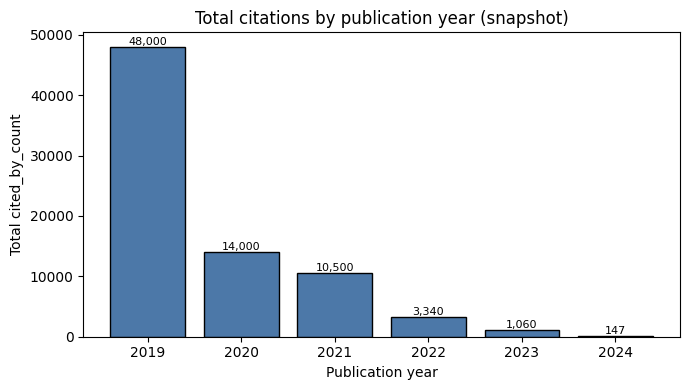

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_year.index.astype(str), by_year.values, color="#4C78A8", edgecolor="black")
ax.set_title("Total citations by publication year (snapshot)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Total cited_by_count")
for x, y in zip(by_year.index.astype(str), by_year.values):
    ax.text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

That downward slope is the **citation-lag** effect: 2019's papers have had five extra years to be cited, so they dominate the total even though 2024 has just as many papers. A real profiling tool would normalise by *age* — but the raw picture already tells a story, and it took one `groupby`.

## 8. Limits and good citizenship

OpenAlex is a public good funded on a shoestring. Use it like a considerate guest:

- **⚠️ Respect the rate limits.** ≤ 10 requests/second, ≤ 100,000/day on the public API. Add your `mailto` (polite pool). If you need millions of records, download the **full data snapshot** (a bulk dump) instead of crawling the API.
- **⚠️ Cache what you fetch.** Save results to disk (JSON/parquet) and re-read them — don't re-hit the API every run. Your analysis becomes reproducible *and* kind to the server.
- **⚠️ Attribute, and know the licence.** OpenAlex data is released **CC0** (public domain) — generous, but cite OpenAlex so others can trace your data.
- **⚠️ Handle nulls and missing entities.** As you saw, `source` and `primary_location` can be `null`; some works have no `authorships`. Defensive parsing isn't optional.
- **⚠️ Watch the access model.** Keys are being introduced (see §3). Read `docs.openalex.org` before building something long-lived, and keep your fetch layer swappable (as `fetch_openalex` is).

> 🧠 **Portable lesson.** Everything here — identify yourself, filter server-side, page with a cursor, cache, respect limits, defend against nulls — is how you use *any* well-designed REST API, not just OpenAlex. GitHub, Crossref, Semantic Scholar, data.gov: same playbook.

## 🧪 Practice exercises

Work on the pinned `WORKS` / `CANNED_WORKS` snapshot so answers are reproducible. Try each before opening the solution.

### Exercise 1 — ⭐ Recent work

Return a list of the titles of every work published in **2022 or later**, sorted newest-first. (This is the `filter=publication_year:2022-2024` query, done locally.)

In [17]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
recent = sorted((w for w in WORKS if w["publication_year"] >= 2022),
                key=lambda w: w["publication_year"], reverse=True)
for w in recent:
    print(w["publication_year"], "-", w["display_name"])
print(f"\n{len(recent)} works from 2022 onward")
```

On the live API: `GET /works?filter=publication_year:2022-2024&sort=publication_date:desc`.
</details>

### Exercise 2 — ⭐⭐ Most prolific authors

Across all works, count how many works each author appears on, and print the **top 5**. (Hint: iterate `w["authorships"]` and read `author["display_name"]`.)

In [18]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from collections import Counter

author_counts = Counter(
    a["author"]["display_name"]
    for w in WORKS
    for a in w["authorships"]
)
for name, n in author_counts.most_common(5):
    print(f"{n:2}  {name}")
```

This is a tiny version of what the `authors` endpoint gives you directly (`works_count`) — but computing it from `works` shows how you traverse the graph edge `works -> authors` yourself.
</details>

### Exercise 3 — ⭐⭐ Venue breakdown (mind the nulls)

Build a `Counter` of venue names across `WORKS`, mapping any work with a **null source** (or null `primary_location`) to the label `"(unknown / preprint)"`. Print every venue with its count.

In [19]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from collections import Counter

def venue_of(w):
    location = w.get("primary_location") or {}
    source = location.get("source") or {}
    return source.get("display_name") or "(unknown / preprint)"

venues = Counter(venue_of(w) for w in WORKS)
for name, n in venues.most_common():
    print(f"{n:2}  {name}")
```

The `or {}` chain is what keeps the three null-shaped works from crashing the count — exactly the guard from §6.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

The cell below tries to collect every venue name in one slick comprehension. It looks fine — and it **crashes on real data**. Run it, read the traceback, then write a fixed version that returns a clean list (using `"(unknown)"` for missing venues).

In [20]:
# ⚠️ THIS CELL INTENTIONALLY ERRORS — read the traceback, then fix it below.
# "Just grab every venue name" — but primary_location / source can be null.
venues = [w["primary_location"]["source"]["display_name"] for w in WORKS]
print(venues)

TypeError: 'NoneType' object is not subscriptable

<details>
<summary>💡 <b>Solution</b></summary>

The snapshot contains works where `primary_location` is `null` **and** works where `primary_location` exists but its `source` is `null`. Indexing into `None` raises `TypeError: 'NoneType' object is not subscriptable`. Guard every hop:

```python
def venue_name(w):
    location = w.get("primary_location") or {}
    source = location.get("source") or {}
    return source.get("display_name") or "(unknown)"

venues = [venue_name(w) for w in WORKS]
print(venues)
print("clean rows:", len(venues), "| unknowns:", venues.count("(unknown)"))
```

**Lesson.** The happy path in the docs ("every work has a source") is a lie the moment you touch real data. Chain `.get(...) or {}` and provide a default — never assume a nested field exists.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ A reusable `fetch_all`

Write `fetch_all(filter_str, per_page=5, max_records=100)` that cursor-pages through `fetch_openalex(..., use_live=False)` and returns **at most** `max_records` works matching `filter_str`. It must (a) follow `next_cursor`, (b) stop at `max_records`, and (c) never loop forever.

In [21]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
def fetch_all(filter_str="", per_page=5, max_records=100):
    out, cursor, pages = [], "*", 0
    while cursor and len(out) < max_records and pages < 1000:   # triple safety net
        resp = fetch_openalex("works",
                              {"filter": filter_str, "per-page": per_page, "cursor": cursor},
                              use_live=False, verbose=False)
        out.extend(resp["results"])
        cursor = resp["meta"]["next_cursor"]
        pages += 1
    return out[:max_records]

got = fetch_all("publication_year:2019", per_page=2)
print(len(got), "works:", [w["display_name"][:30] for w in got])
```

The three guards — `cursor`, `len(out) < max_records`, `pages < 1000` — mean the loop halts on *any* of "no more data", "enough data", or "something's wrong". Production pagination always has a hard page cap.
</details>

### Stretch exercise B — ⭐⭐⭐ Co-authorship pairs

Find the most frequent **co-author pairs**: for each work, take every unordered pair of its authors and tally how often each pair appears together. Print the top 3 collaborations. (Hint: `itertools.combinations`, and sort each pair so `(A, B)` and `(B, A)` count as one.)

In [22]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from collections import Counter
from itertools import combinations

pairs = Counter()
for w in WORKS:
    names = sorted(a["author"]["display_name"] for a in w["authorships"])
    for pair in combinations(names, 2):        # unordered pairs, deduped by sorting
        pairs[pair] += 1

for (a, b), n in pairs.most_common(3):
    print(f"{n}x  {a}  +  {b}")
```

You just built a slice of the **co-authorship network** from raw `works` data — the kind of graph analysis (NB 14's cousin) that OpenAlex's structured output makes trivial and scraping makes almost impossible.
</details>

## 🎁 Bonus mini-project — Profile a research topic

Put it all together into a small **topic profiler**. Given the snapshot (or a live `filter=`), produce a one-screen profile:

1. **Volume:** number of works per year (a bar chart).
2. **Impact:** the 5 most-cited works (title + `cited_by_count`).
3. **Venues:** the top journals/conferences the work appears in (nulls handled).
4. **People:** the 3 most prolific authors.

Wrap it in `profile_topic(works)` so you can point it at any result set — canned today, live tomorrow.

In [23]:
# Your code here  👇


<details>
<summary>💡 <b>Solution sketch</b></summary>

```python
from collections import Counter

def profile_topic(works, title="Topic profile"):
    df = pd.DataFrame([flatten_work(w) for w in works])
    print(f"=== {title} — {len(df)} works ===\n")

    print("Works per year:")
    print(df["year"].value_counts().sort_index().to_string(), "\n")

    print("Most cited:")
    for _, r in df.nlargest(5, "cited_by_count").iterrows():
        print(f"  {r['cited_by_count']:>6,}  {r['title']}")

    print("\nTop venues:")
    print(df["venue"].fillna("(unknown / preprint)").value_counts().head(5).to_string())

    authors = Counter(a["author"]["display_name"] for w in works for a in w["authorships"])
    print("\nMost prolific authors:")
    for name, n in authors.most_common(3):
        print(f"  {n:2}  {name}")

    ax = df["year"].value_counts().sort_index().plot(kind="bar", color="#4C78A8", edgecolor="black")
    ax.set_title(title); ax.set_xlabel("Year"); ax.set_ylabel("# works")
    plt.tight_layout(); plt.show()

profile_topic(WORKS, "Graph Neural Networks (snapshot)")
```

To run it live, opt in explicitly with `use_live=True`: `profile_topic(fetch_openalex("works", {"filter": "primary_topic.id:T10001", "per-page": 200}, use_live=True)["results"])`.
</details>

## 🧠 Key takeaways

1. **Check for an API before you scrape.** OpenAlex turns "collect scholarly data" from a fragile HTML-parsing job into a clean JSON query. When a good API exists, scraping is the wrong tool.
2. **It's a graph, not a pile of documents.** Query one entity (`works`, `authors`, `sources`, `institutions`, `topics`, `publishers`, `funders`) and expand along the edges.
3. **No key required — but join the polite pool** with `mailto=`, and stay under the limits (~10/s, ~100k/day). API etiquette is the robots.txt of the API world.
4. **`filter=` for exact facts, `search=` for fuzzy words** — and both run *server-side*, so you download only what you asked for.
5. **Page big result sets with a cursor:** `cursor=*` → follow `meta['next_cursor']` until `None`, and **always cap** the loop.
6. **Flatten defensively.** `primary_location`, its `source`, and `authorships` can be null/empty — chain `.get(...) or {}` and provide defaults.
7. **Be a good citizen:** cache results, attribute the CC0 data, prefer the bulk snapshot for huge pulls, and keep your fetch layer swappable as the access model evolves.

## ✅ Self-assessment

- [ ] I can explain when an open API is a better data source than scraping HTML.
- [ ] I can name the OpenAlex entities and sketch how they link into a graph.
- [ ] I can request a Work and read `id`, `display_name`, `publication_year`, `cited_by_count`, `authorships`, and `primary_location.source`.
- [ ] I can join the polite pool with `mailto=` and state the rate limits.
- [ ] I can build a query with `filter=` and `search=`.
- [ ] I can cursor-paginate a full result set and cap the loop safely.
- [ ] I can flatten nested Works into a null-safe pandas `DataFrame` and chart an insight.

## 🚀 Next step

You've now seen both sides of "web data": **scrape it** (NB 14, NB 15) and **query an open API** (this lesson). Head back to the **Module 4 `README.md`** to review the full web-scraping track, then put these skills to work on something real in the **capstone projects** under [`../15_capstones/`](../15_capstones/) — several of them start with exactly this step: *pull a clean dataset from the web, then build on it.*